In [1]:
pip install pandas sqlalchemy psycopg2-binary matplotlib seaborn

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB 435.7 kB/s eta 0:00:07
   - -------------------------------------- 0.1/2.7 MB 1.1 MB/s eta 0:00:03
   --- ------------------------------------ 0.3/2.7 MB 1.7 MB/s eta 0:00:02
   ------ --------------------------------- 0.5/2.7 MB 2.5 MB/s eta 0:00:01
   ------ --------------------------------- 0.5/2.7 MB 2.5 MB/s eta 0:00:01
   ----------- ---------------------------- 0.8/2.7 MB 2.8 MB/s eta 0:00:01
   ----------------- ---------------------- 1.2/2.7 MB 3.7 MB/s eta 0:00:01
   ----------------------- ---------------- 1.6/2.7 MB 4.4 MB/s eta 0:00:01
   ----------------------------- ---------- 2.0/2.7 MB 4.7 MB/s eta 0:00:01
   ----------------------------------- ---- 2.4/2.7 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------  2.7/2.7 MB 5.3 MB/s eta 0:00:01
   ---------------------

In [1]:
from sqlalchemy import create_engine
import pandas as pd


In [2]:
DB_USER = 'admin'
DB_PASSWORD = 'admin123'
DB_HOST = 'localhost'
DB_PORT = '5433'
DB_NAME = 'wb_reviews'

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# query = 
# SELECT 
    # wp.nm_id,
    # wp.id AS wb_prod_id,
    # wp.imt_name,
    # wp.subj_name,
    # wp.subj_root_name,
    # wp.nm_colors_names,
    # wp.description,
    # wp.brand_name,
    # wr.id AS wb_rev_id,
    # wr.product_valuation,
    # wr.color,
    # wr.review_text,
    # wr.answer,
    # wr.word_count,
    # wr.text_length
# FROM wb_products wp
# INNER JOIN wb_reviews wr ON wp.nm_id = wr.nm_id;
# """
# 
# df = pd.read_sql(query, engine)

In [5]:
query_text_length = """
SELECT text_length FROM wb_reviews;
"""

# Если отзывов очень много, можно ограничить количество, например:
# query_text_length = "SELECT text_length FROM wb_reviews LIMIT 10000;"

df_lengths = pd.read_sql(query_text_length, engine)
print(f"Загружено {len(df_lengths)} записей о длине отзывов")

Загружено 34663015 записей о длине отзывов


D:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


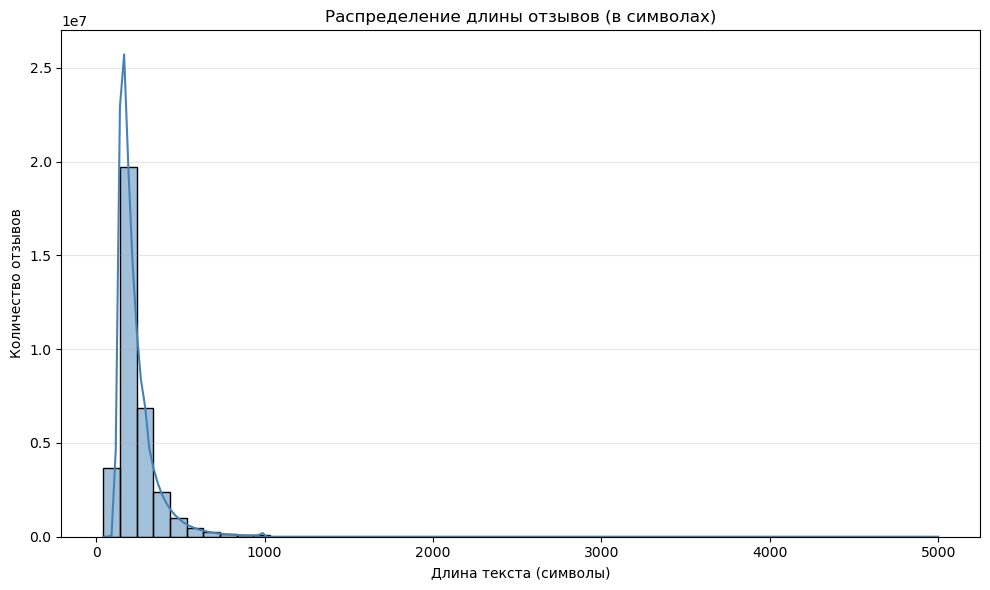

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_lengths, x='text_length', bins=50, kde=True, color='steelblue')
plt.title('Распределение длины отзывов (в символах)')
plt.xlabel('Длина текста (символы)')
plt.ylabel('Количество отзывов')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

D:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


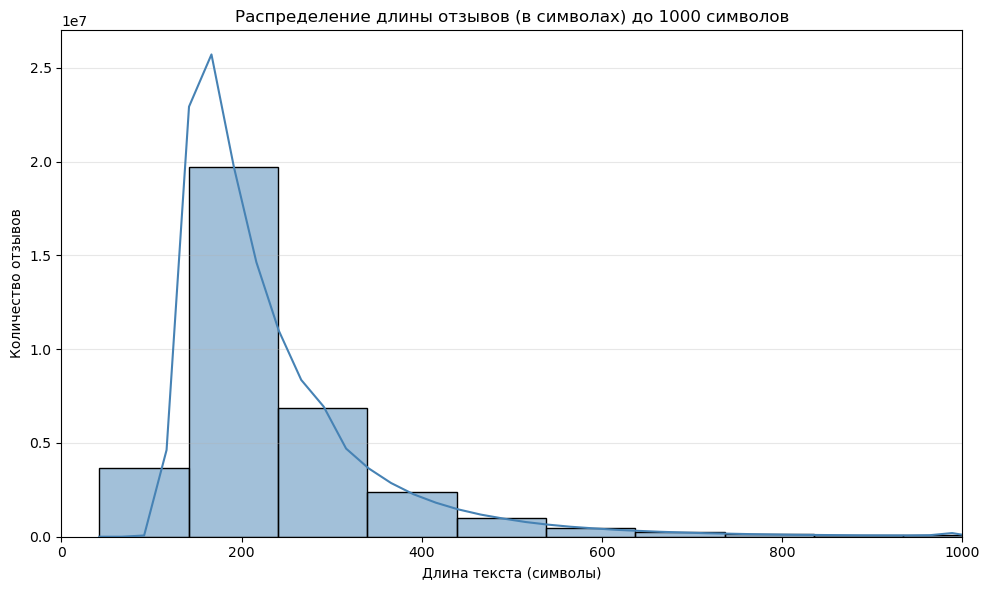

In [16]:
query_len = "SELECT text_length FROM wb_reviews;"
df_len = pd.read_sql(query_len, engine)

# Построение гистограммы с ограничением по оси X
plt.figure(figsize=(10, 6))
sns.histplot(data=df_len, x='text_length', bins=50, kde=True, color='steelblue')
plt.xlim(0, 1000)  # Ограничиваем ось X
plt.title('Распределение длины отзывов (в символах) до 1000 символов')
plt.xlabel('Длина текста (символы)')
plt.ylabel('Количество отзывов')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

D:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


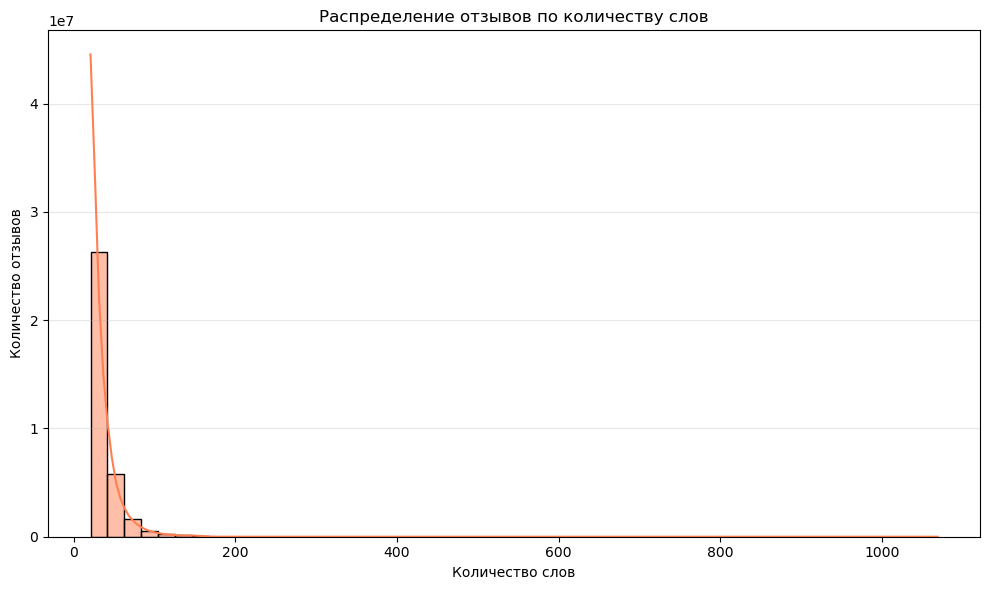

In [12]:
query_word_count = "SELECT word_count FROM wb_reviews;"
df_words = pd.read_sql(query_word_count, engine)

plt.figure(figsize=(10, 6))
sns.histplot(data=df_words, x='word_count', bins=50, kde=True, color='coral')
plt.title('Распределение отзывов по количеству слов')
plt.xlabel('Количество слов')
plt.ylabel('Количество отзывов')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

D:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


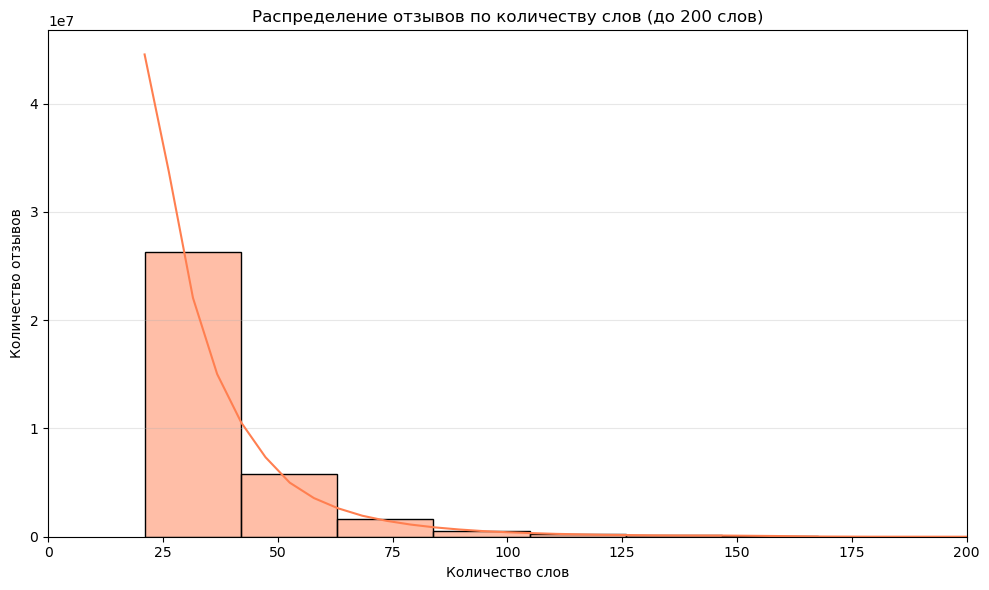

In [17]:
# Запрос количества слов
query_words = "SELECT word_count FROM wb_reviews;"
df_words = pd.read_sql(query_words, engine)

plt.figure(figsize=(10, 6))
sns.histplot(data=df_words, x='word_count', bins=50, kde=True, color='coral')
plt.xlim(0, 200)  # Ограничиваем ось X
plt.title('Распределение отзывов по количеству слов (до 200 слов)')
plt.xlabel('Количество слов')
plt.ylabel('Количество отзывов')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# подсчёт уникальных категорий
query_count = "SELECT COUNT(DISTINCT subj_root_name) AS unique_categories FROM wb_products;"
df_count = pd.read_sql(query_count, engine)
print(f"Всего уникальных категорий верхнего уровня: {df_count['unique_categories'][0]}")

Всего уникальных категорий верхнего уровня: 68


In [14]:
#получение всех уникальных названий категорий
query_list = "SELECT DISTINCT subj_root_name FROM wb_products ORDER BY subj_root_name;"
df_list = pd.read_sql(query_list, engine)

print("Список категорий:")
print(df_list.to_string(index=False)) 

Список категорий:
                          subj_root_name
                                        
                    Автомобильные товары
                         Автоэлектроника
                              Аксессуары
                    Аксессуары для волос
                  Аксессуары для малышей
                    Аксессуары для обуви
                                   Белье
                       Белье для малышей
                               Бижутерия
                         Бытовая техника
                         Восстановленные
                     Все для садоводства
                          Головные уборы
                         Детское питание
                           Для праздника
                                     Дом
                       Запчасти для авто
                                Здоровье
                  Игровые консоли и игры
                                 Игрушки
                     Канцелярские товары
               Книжная продукция и диск

In [15]:
# категории + статистика по отзывам
query_stats = """
SELECT 
    p.subj_root_name,
    COUNT(r.id) AS total_reviews,
    COUNT(CASE WHEN r.word_count BETWEEN 20 AND 30 THEN 1 END) AS min_reviews,   -- 20-30 слов
    COUNT(CASE WHEN r.word_count BETWEEN 31 AND 50 THEN 1 END) AS mid_reviews,   -- 31-50 слов
    COUNT(CASE WHEN r.word_count > 50 THEN 1 END) AS long_reviews                -- более 50 слов
FROM wb_products p
LEFT JOIN wb_reviews r ON p.nm_id = r.nm_id
GROUP BY p.subj_root_name
ORDER BY p.subj_root_name;
"""

df_stats = pd.read_sql(query_stats, engine)

# Вывод результатов
print("Статистика по категориям:")
print(df_stats.to_string(index=False))

Статистика по категориям:
                          subj_root_name  total_reviews  min_reviews  mid_reviews  long_reviews
                                                      0            0            0             0
                    Автомобильные товары          23237        12055         7822          3360
                         Автоэлектроника           2486         1063          811           612
                              Аксессуары         440154       207959       165938         66257
                    Аксессуары для волос          16579         9280         5543          1756
                  Аксессуары для малышей           9936         5344         3557          1035
                    Аксессуары для обуви          13622         6411         4804          2407
                                   Белье         335167       165739       124516         44912
                       Белье для малышей          25584        13894         9135          2555
              

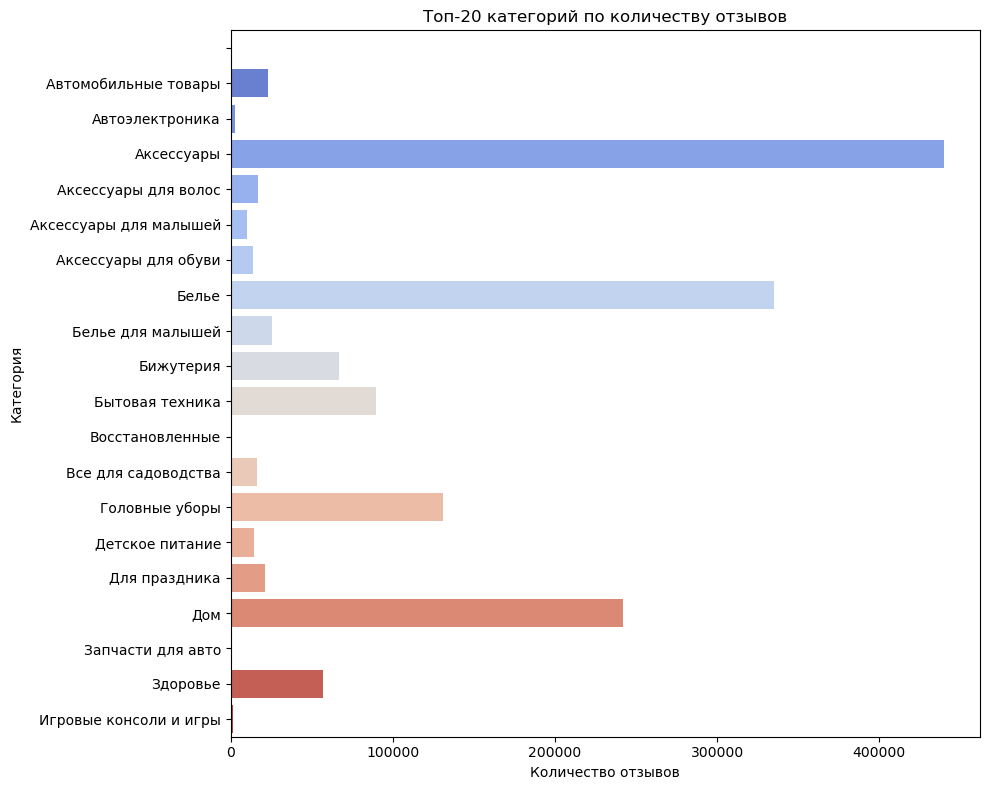

In [25]:
top20 = df_stats.head(20)
plt.figure(figsize=(10, 8))
sns.barplot(data=top20, x='total_reviews', y='subj_root_name', palette='coolwarm')
plt.title('Топ-20 категорий по количеству отзывов')
plt.xlabel('Количество отзывов')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

In [21]:
# подсчёт уникальных подкатегорий
query_count = "SELECT COUNT(DISTINCT subj_name) AS unique_undercategories FROM wb_products;"
df_count = pd.read_sql(query_count, engine)
print(f"Всего уникальных подкатегорий: {df_count['unique_undercategories'][0]}")

Всего уникальных подкатегорий: 5585


In [20]:
#получение всех уникальных названий подкатегорий
query_list = "SELECT DISTINCT subj_name FROM wb_products ORDER BY subj_name;"
df_list = pd.read_sql(query_list, engine)

print("Список поодкатегорий:")
print(df_list.to_string(index=False)) 

Список поодкатегорий:
                                      subj_name
                                               
                                        3D очки
                                    3D-принтеры
                                       3D-ручки
                                    AV-ресиверы
                                       BB-кремы
                          Blu-Ray проигрыватели
                                       CC-кремы
                               CD проигрыватели
                                       DD-кремы
                                 DJ контроллеры
                                     DVD-плееры
                                FM-трансмиттеры
                               Flash-накопители
                                    GPS-трекеры
                                   Hi-Fi плееры
                                    L-карнитины
                                     MP3 плееры
                                   Mesh системы
                  

In [22]:
# запрос для подсчёта товаров с более чем одним отзывом в каждой категории (то есть число товаров на которые больше одного отзыва)
query = """
SELECT 
    subj_root_name,
    COUNT(*) AS products_with_multiple_reviews
FROM (
    SELECT 
        p.subj_root_name,
        p.nm_id
    FROM wb_products p
    INNER JOIN wb_reviews r ON p.nm_id = r.nm_id
    GROUP BY p.nm_id, p.subj_root_name
    HAVING COUNT(r.id) > 1
) AS t
GROUP BY subj_root_name
ORDER BY products_with_multiple_reviews DESC;
"""

df_multiple = pd.read_sql(query, engine)
print(f"Найдено категорий: {len(df_multiple)}")
df_multiple.head(10)

Найдено категорий: 64


,subj_root_name,products_with_multiple_reviews
0,Одежда,501311
1,Обувь,197130
2,Аксессуары,81815
3,Красота,47668
4,Белье,45757
5,Дом,36123
6,Игрушки,27180
7,Головные уборы,24347
8,Спортивная одежда,21527
9,Посуда и инвентарь,19759


Распределение оценок:
   product_valuation     count
0                  1   3258169
1                  2   1623600
2                  3   3231117
3                  4   4853953
4                  5  21696176


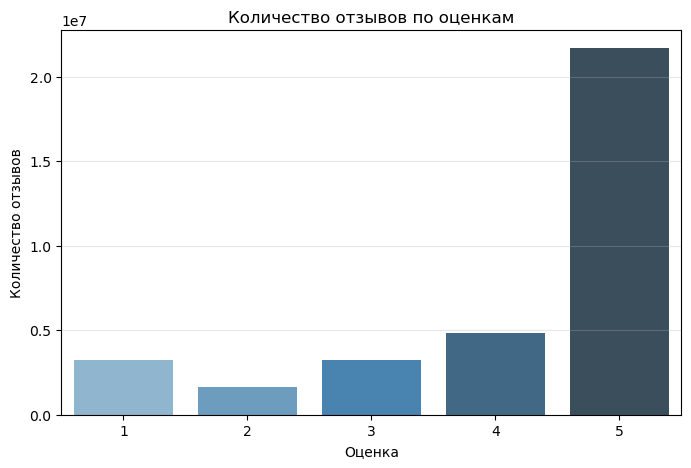

In [29]:
#  количество отзывов для каждой оценки
query_ratings = """
SELECT 
    product_valuation,
    COUNT(*) AS count
FROM wb_reviews
GROUP BY product_valuation
ORDER BY product_valuation;
"""

df_ratings = pd.read_sql(query_ratings, engine)
print("Распределение оценок:")
print(df_ratings)
plt.figure(figsize=(8, 5))
sns.barplot(data=df_ratings, x='product_valuation', y='count', palette='Blues_d')
plt.title('Количество отзывов по оценкам')
plt.xlabel('Оценка')
plt.ylabel('Количество отзывов')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [30]:

# количество отзывов с каждой оценкой по категориям
query_ratings_by_cat = """
SELECT 
    p.subj_root_name,
    COUNT(r.id) AS total_reviews,
    COUNT(CASE WHEN r.product_valuation = 1 THEN 1 END) AS rating_1,
    COUNT(CASE WHEN r.product_valuation = 2 THEN 1 END) AS rating_2,
    COUNT(CASE WHEN r.product_valuation = 3 THEN 1 END) AS rating_3,
    COUNT(CASE WHEN r.product_valuation = 4 THEN 1 END) AS rating_4,
    COUNT(CASE WHEN r.product_valuation = 5 THEN 1 END) AS rating_5
FROM wb_products p
LEFT JOIN wb_reviews r ON p.nm_id = r.nm_id
GROUP BY p.subj_root_name
ORDER BY total_reviews DESC;
"""

df_ratings_cat = pd.read_sql(query_ratings_by_cat, engine)

print("Статистика по категориям (распределение оценок):")
print(df_ratings_cat.to_string(index=False))

Статистика по категориям (распределение оценок):
                          subj_root_name  total_reviews  rating_1  rating_2  rating_3  rating_4  rating_5
                                  Одежда        3078455    143630    123167    321009    557028   1933621
                                   Обувь        1251488     75846     52028    125229    221903    776482
                                 Красота         798540     83953     39953     71659     91479    511496
                              Аксессуары         440154     31076     19704     43265     69293    276816
                                   Белье         335167     25260     16175     35994     55832    201906
                                 Игрушки         269324     28225     13391     26194     38122    163392
                                     Дом         241797     23777     12962     24866     33853    146339
                      Посуда и инвентарь         151896     18295      8288     14043     18413     928